<a href="https://colab.research.google.com/github/doa-2026/machine-learning/blob/main/classification_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load and check Data

In [1]:
path="/content/drive/MyDrive/نسخة من stroke.csv"
import pandas as pd
df=pd.read_csv(path)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1192,Female,31,0,0,No,Govt_job,Rural,70.66,27.2,never smoked,0
1,77,Female,13,0,0,No,children,Rural,85.81,18.6,Unknown,0
2,59200,Male,18,0,0,No,Private,Urban,60.56,33.0,never smoked,0
3,24905,Female,65,0,0,Yes,Private,Urban,205.77,46.0,formerly smoked,1
4,24257,Male,4,0,0,No,children,Rural,90.42,16.2,Unknown,0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df["stroke"].value_counts()
# its abinary classifcation ,,, not balanced

,count
stroke,
0,1000
1,137


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report , accuracy_score ,confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn import set_config
set_config(transform_output="pandas")
from sklearn.preprocessing import StandardScaler,OrdinalEncoder, OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier , BaggingClassifier
from sklearn.tree import DecisionTreeClassifier


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,52


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1137 entries, 0 to 1136
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1137 non-null   int64  
 1   gender             1137 non-null   object 
 2   age                1137 non-null   object 
 3   hypertension       1137 non-null   int64  
 4   heart_disease      1137 non-null   int64  
 5   ever_married       1137 non-null   object 
 6   work_type          1137 non-null   object 
 7   Residence_type     1137 non-null   object 
 8   avg_glucose_level  1137 non-null   float64
 9   bmi                1085 non-null   float64
 10  smoking_status     1137 non-null   object 
 11  stroke             1137 non-null   int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 106.7+ KB


Train - Test  Split

In [8]:
target="stroke"
X=df.drop(columns=target)
y=df[target]
X_train ,X_test,y_train ,y_test =train_test_split(X,y,random_state=42)


In [9]:
num_col=X_train.select_dtypes("number").columns
cat_col=X_train.select_dtypes("object").columns
#columns of number
num_imp=SimpleImputer(strategy="mean")
scale=StandardScaler()
num_pip=make_pipeline(num_imp,scale)
num_tap=("number", num_pip , num_col)

#catagorical
cat_imp=SimpleImputer(strategy="constant",fill_value="missing")
encoder=OneHotEncoder(handle_unknown="ignore",sparse_output=False)
cat_pip=make_pipeline(cat_imp,encoder)
cat_tap=("cat",cat_pip,cat_col)
# Colunmn Transformer
preprocessor=ColumnTransformer([num_tap,cat_tap],verbose_feature_names_out=False)
preprocessor



ColumnTransformer(transformers=[('number',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['id', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                  verbose_feature_names_out=False)

Instantiate and Fit the Model

In [10]:
tree=DecisionTreeClassifier(random_state=42)
#make pipline
pip_tree=make_pipeline(preprocessor,tree)
pip_tree.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('number',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['id', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['gender', 'age', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

In [25]:
y_test_pre=pip_tree.predict(X_test)
y_tain_pre=pip_tree.predict(X_train)
print(classification_report(y_test,y_test_pre))

              precision    recall  f1-score   support

           0       0.90      0.90      0.90       251
           1       0.24      0.24      0.24        34

    accuracy                           0.82       285
   macro avg       0.57      0.57      0.57       285
weighted avg       0.82      0.82      0.82       285



In [12]:
#Evalute the Model
r=accuracy_score(y_test,y_test_pre)
r

0.8210526315789474

In [13]:
#create a confusion matrix
cm=confusion_matrix(y_test,y_test_pre)
cm

array([[226,  25],
       [ 26,   8]])

In [14]:
cm_df=pd.DataFrame(cm)
cm_df

,0,1
0,226,25
1,26,8


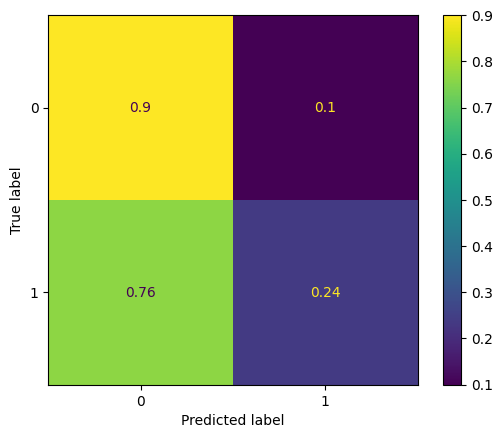

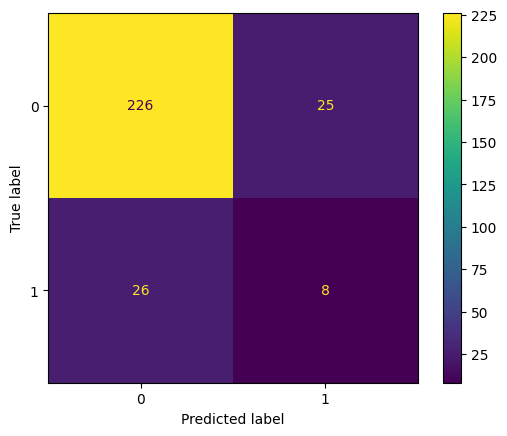

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pre,normalize="true")
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pre)

1-the accuracy of model  is 0.82 this mean that the model has 80%  is correctly of prediction

2-False postive 0.1
3-False negative 0.76

4-as result above , when 1  as postive class both precsion and recall .24
which is not good
